# Social Engine Posts — Exploratory Data Analysis

This notebook performs exploratory data analysis on the cleaned Social Engine
Posts dataset.

The analysis focuses on understanding data distributions, engagement
patterns, platform behaviour, temporal activity, missing-value patterns,
relationships between variables, and potentially meaningful anomalies.

The analysis is performed only on the cleaned dataset produced during the
data-cleaning stage.

## STEP 1 — Load Cleaned Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the cleaned Posts dataset.
posts = pd.read_csv('/content/Social_Engine_Posts_Cleaned.csv')

# Convert timestamp back to datetime after loading the CSV.
posts['timestamp'] = pd.to_datetime(posts['timestamp'])

print("Dataset loaded successfully.")
print("Shape:", posts.shape)

Dataset loaded successfully.
Shape: (12000, 8)


In [2]:
# Display the first five records.
posts.head()

,post_id,user_id,platform,text_content,timestamp,likes,shares,comments
0,to64mgey2v3y,user_vfxs1pry,Reddit,Bummed out with my new Air Max from Nike! Abso...,2024-09-25 00:00:00,4488.0,1456,673
1,7f0wdauzbj89,user_8l7rv5oe,Reddit,My one month review of Pepsi Crystal Pepsi: Hi...,2024-08-01 16:14:00,789.0,1484,39
2,dvvhg8eel45x,user_nfo3ih5u,NaN,Just unboxed my new Highlander from Toyota. Ex...,2025-04-13 20:12:18,NaN,1410,839
3,hgb9cxke4t7b,user_27aje6ur,Facebook,Comparing Pepsi Crystal Pepsi to the competiti...,2024-09-10 00:00:00,167.0,584,833
4,zwerpw3wk320,user_9px5q0by,Reddit,My one week review of Coca-Cola Diet Coke: Bes...,2024-05-31 00:00:00,4749.0,152,630


In [3]:
# Display the dataset structure and data types.
posts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   post_id       12000 non-null  object        
 1   user_id       12000 non-null  object        
 2   platform      10216 non-null  object        
 3   text_content  10260 non-null  object        
 4   timestamp     12000 non-null  datetime64[ns]
 5   likes         9677 non-null   float64       
 6   shares        12000 non-null  int64         
 7   comments      12000 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(2), object(4)
memory usage: 750.1+ KB


In [4]:
# Generate descriptive statistics for numerical columns.
posts[['likes', 'shares', 'comments']].describe()

,likes,shares,comments
count,9677.000000,12000.000000,12000.00000
mean,2493.505115,1007.167167,504.34575
std,1438.286521,575.072282,288.68416
min,0.000000,0.000000,0.00000
25%,1240.000000,510.000000,253.00000
50%,2502.000000,1018.000000,503.00000
75%,3724.000000,1501.000000,755.00000
max,5000.000000,2000.000000,1000.00000


## STEP 2 — Dataset Overview and Data Quality Profile

This section establishes a baseline profile of the cleaned Posts dataset.

We examine the number of records, unique posts and users, platform coverage,
missing-value distribution, and numerical engagement coverage. These checks
provide context for interpreting the subsequent exploratory analysis.

In [5]:
# Basic dataset dimensions.
print("Number of posts:", len(posts))
print("Number of columns:", posts.shape[1])

# Unique identifiers.
print("Unique post IDs:", posts['post_id'].nunique())
print("Unique user IDs:", posts['user_id'].nunique())

# Timestamp coverage.
print("Earliest post:", posts['timestamp'].min())
print("Latest post:", posts['timestamp'].max())

Number of posts: 12000
Number of columns: 8
Unique post IDs: 12000
Unique user IDs: 1500
Earliest post: 2024-05-01 00:00:00
Latest post: 2025-04-30 21:57:10


In [6]:
# Calculate missing values and their percentages for every column.
missing_profile = pd.DataFrame({
    'Missing Values': posts.isna().sum(),
    'Missing Percentage': (posts.isna().mean() * 100).round(2)
})

missing_profile

,Missing Values,Missing Percentage
post_id,0,0.00
user_id,0,0.00
platform,1784,14.87
text_content,1740,14.50
timestamp,0,0.00
likes,2323,19.36
shares,0,0.00
comments,0,0.00


In [7]:
# Count posts by platform, including missing platform values.
platform_counts = posts['platform'].value_counts(dropna=False)

platform_counts

,count
platform,
Facebook,2074
YouTube,2073
Twitter,2049
Reddit,2031
Instagram,1989
NaN,1784


In [8]:
# Count valid observations for each engagement metric.
engagement_coverage = pd.DataFrame({
    'Valid Values': posts[['likes', 'shares', 'comments']].notna().sum(),
    'Missing Values': posts[['likes', 'shares', 'comments']].isna().sum()
})

engagement_coverage

,Valid Values,Missing Values
likes,9677,2323
shares,12000,0
comments,12000,0


## STEP 3 — Platform Distribution

This section examines the distribution of posts across social media platforms.

The analysis includes posts with known platform values and separately reports
records where the platform is missing. This prevents missing platform information
from being silently excluded from the analysis.

In [9]:
# Count posts for each platform, including missing platform values.
platform_counts = posts['platform'].value_counts(dropna=False)

print("Posts by platform:")
print(platform_counts)

Posts by platform:
platform
Facebook     2074
YouTube      2073
Twitter      2049
Reddit       2031
Instagram    1989
NaN          1784
Name: count, dtype: int64


In [10]:
# Calculate the percentage of total posts represented by each platform.
platform_distribution = pd.DataFrame({
    'Post Count': platform_counts,
    'Percentage': (platform_counts / len(posts) * 100).round(2)
})

# Give the missing category a readable label for the report.
platform_distribution.index = platform_distribution.index.fillna('Missing')

platform_distribution

,Post Count,Percentage
platform,,
Facebook,2074,17.28
YouTube,2073,17.27
Twitter,2049,17.08
Reddit,2031,16.92
Instagram,1989,16.58
Missing,1784,14.87


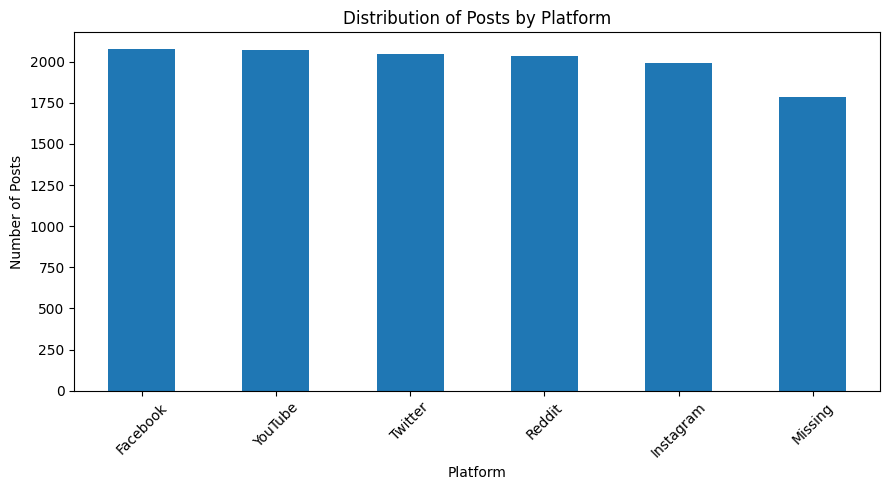

In [11]:
# Plot the distribution of posts across platforms.
# Missing platform values are retained as a separate category.

platform_distribution['Post Count'].plot(
    kind='bar',
    figsize=(9, 5),
    title='Distribution of Posts by Platform',
    ylabel='Number of Posts',
    xlabel='Platform'
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Insight

*   Facebook and YouTube have the highest number of posts, but the difference
between the five known platforms is small.
*   This indicates that the dataset
has a relatively balanced representation of platforms.
*  Missing platform
information accounts for 14.87% of all posts and should therefore be retained
as a separate category during platform-level analysis.


## STEP 4 — Engagement Distribution

This section analyses the distribution of likes, shares, and comments across
posts. Histograms are used to identify the typical range, spread, and
potentially unusual concentrations of engagement values.

Missing engagement values are excluded from the distribution plots rather than
being treated as zero, since missing and zero represent different conditions.

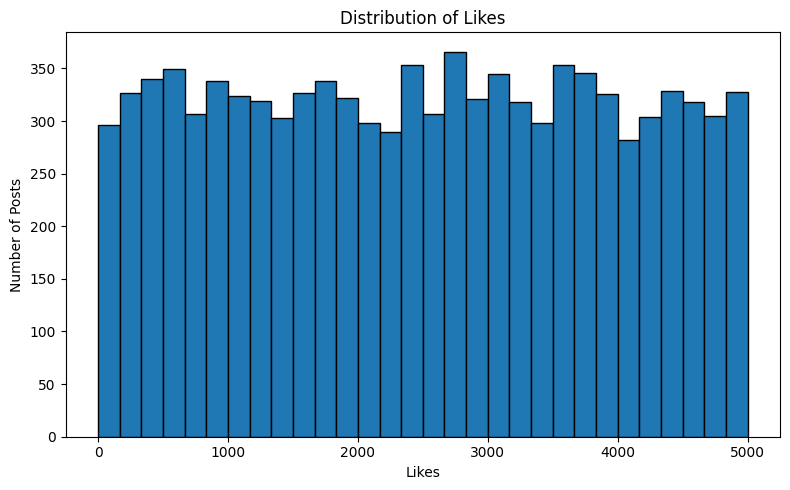

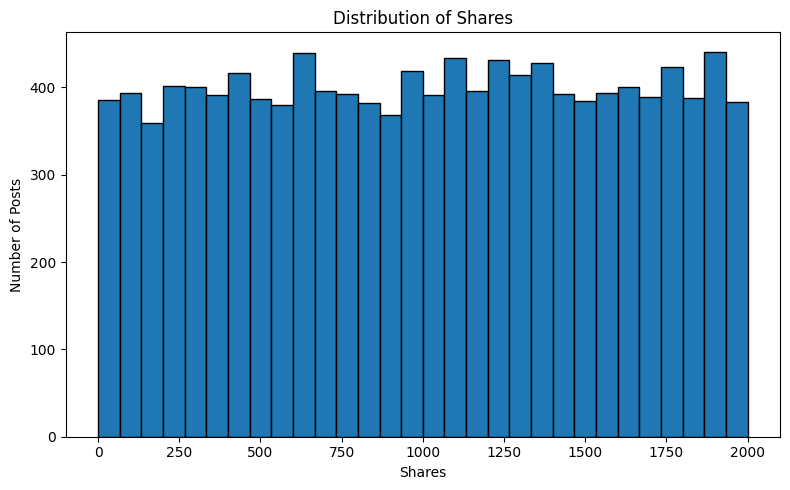

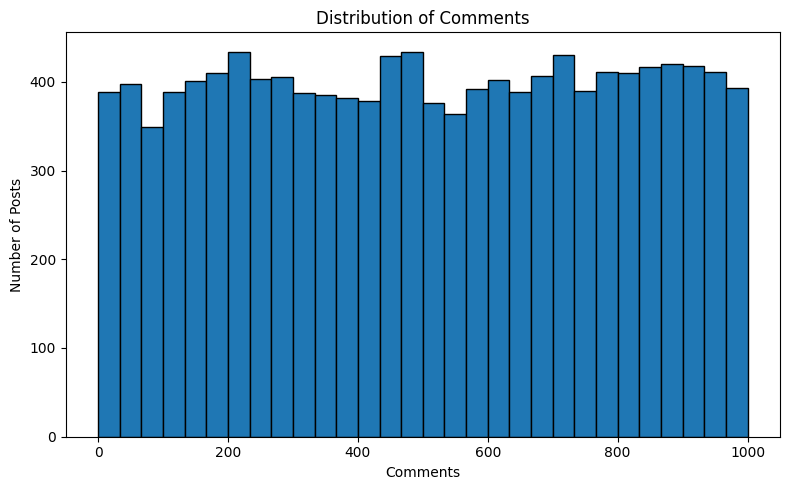

In [12]:
# Plot the distribution of each engagement metric.
# Missing values are excluded from the plots.

engagement_columns = ['likes', 'shares', 'comments']

for column in engagement_columns:

    plt.figure(figsize=(8, 5))

    posts[column].dropna().plot(
        kind='hist',
        bins=30,
        edgecolor='black'
    )

    plt.title(f'Distribution of {column.capitalize()}')
    plt.xlabel(column.capitalize())
    plt.ylabel('Number of Posts')

    plt.tight_layout()
    plt.show()

In [13]:
# Generate descriptive statistics for the engagement variables.
# This helps quantify the centre and spread observed in the histograms.

engagement_stats = posts[engagement_columns].describe().T

engagement_stats

,count,mean,std,min,25%,50%,75%,max
likes,9677.0,2493.505115,1438.286521,0.0,1240.0,2502.0,3724.0,5000.0
shares,12000.0,1007.167167,575.072282,0.0,510.0,1018.0,1501.0,2000.0
comments,12000.0,504.345750,288.684160,0.0,253.0,503.0,755.0,1000.0


### Insight

* The three engagement metrics show broadly spread distributions across their
respective ranges rather than being concentrated around a narrow value.

* Likes range from 0 to 5,000, with a mean of approximately 2,494 and a median
of 2,502.

* Shares range from 0 to 2,000, with a mean of approximately 1,007
and a median of 1,018.
* Comments range from 0 to 1,000, with a mean of
approximately 504 and a median of 503.

* The histograms show relatively even frequencies across the ranges, with no
obvious extreme concentration or isolated spike. This suggests that the
engagement variables in this dataset have broad coverage across their allowed
ranges.

* Likes have 2,323 missing observations, so their distribution is based on fewer
posts than shares and comments.
* Missing likes are therefore excluded from the
distribution analysis rather than being interpreted as zero engagement.

## STEP 5 — Engagement by Platform

This section compares engagement metrics across the identified social media
platforms.

Posts with missing platform information are excluded from platform-specific
comparisons because their platform cannot be reliably determined.

Both mean and median engagement are examined to provide a more complete view
of platform-level engagement patterns.

In [14]:
# Keep only posts with a known platform for platform-level comparison.
platform_posts = posts.dropna(subset=['platform']).copy()

# Calculate mean and median engagement for each platform.
platform_engagement = platform_posts.groupby('platform')[
    ['likes', 'shares', 'comments']
].agg(['mean', 'median']).round(2)

platform_engagement

likes           shares         comments       
              mean  median     mean  median     mean median
platform                                                   
Facebook   2526.55  2573.0   984.17   993.5   506.94  504.0
Instagram  2494.51  2495.0  1040.84  1049.0   499.80  498.0
Reddit     2487.80  2496.0  1002.23  1016.0   511.18  513.0
Twitter    2439.87  2443.5  1005.39  1022.0   506.13  504.0
YouTube    2528.33  2619.5  1011.83  1017.0   504.38  498.0

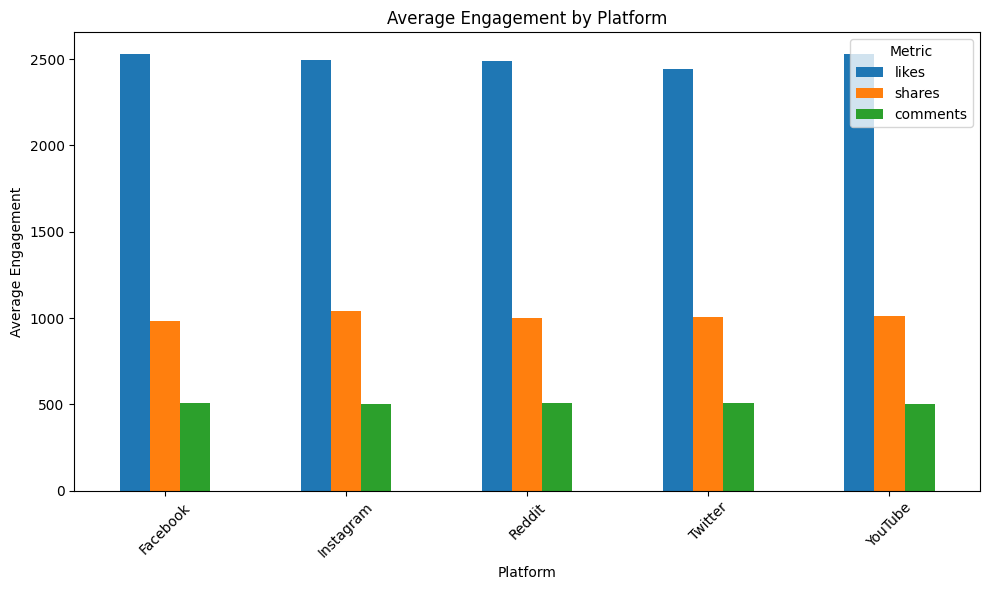

In [15]:
# Calculate average engagement by platform.
platform_mean_engagement = platform_posts.groupby('platform')[
    ['likes', 'shares', 'comments']
].mean()

# Plot average engagement across platforms.
platform_mean_engagement.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Average Engagement by Platform')
plt.xlabel('Platform')
plt.ylabel('Average Engagement')
plt.xticks(rotation=45)
plt.legend(title='Metric')

plt.tight_layout()
plt.show()

### Insight

* Average engagement varies only moderately across the five known platforms.

* YouTube has the highest average likes at approximately 2,528, closely followed
by Facebook at approximately 2,527, while Twitter has the lowest average likes
at approximately 2,440.

* Instagram records the highest average shares at approximately 1,041, whereas
Facebook has the lowest at approximately 984.
* Reddit has the highest average
comments at approximately 511, while Instagram has the lowest at approximately 500.

* The medians are broadly close to the corresponding means across platforms,
indicating that the platform-level engagement patterns are relatively similar
rather than being driven by a large difference in central tendency.

* Overall, no single platform consistently leads across all three engagement
metrics. Platform differences should therefore be considered metric-specific
rather than interpreted as one platform being universally more engaging.

* The comparison of likes is based only on posts with available like values,
since missing likes were retained as missing during data cleaning.

## STEP 6 — Relationships Between Engagement Metrics

This section examines the relationships between likes, shares, and comments.

Pearson correlation is used to measure the strength and direction of linear
relationships between the numerical engagement variables.

Correlation indicates association between variables and does not establish
causation.

In [16]:
# Calculate Pearson correlation between engagement metrics.
# Pairwise valid observations are used automatically.

engagement_corr = posts[['likes', 'shares', 'comments']].corr()

engagement_corr.round(3)

,likes,shares,comments
likes,1.000,-0.003,0.013
shares,-0.003,1.000,0.024
comments,0.013,0.024,1.000


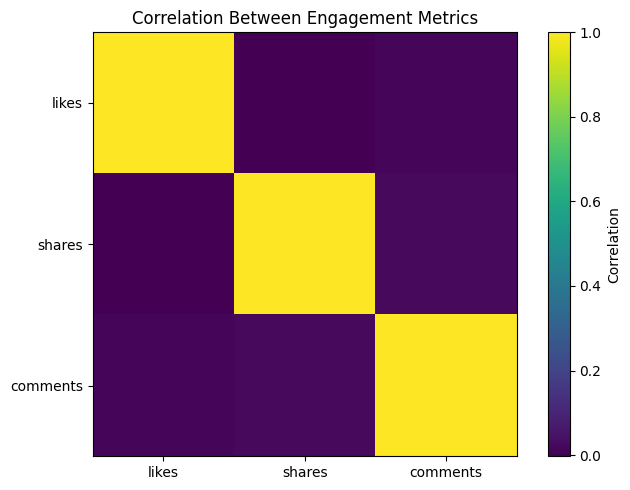

In [17]:
# Visualise the correlation matrix.

plt.figure(figsize=(7, 5))

plt.imshow(
    engagement_corr,
    interpolation='nearest'
)

plt.colorbar(label='Correlation')

plt.xticks(
    range(len(engagement_corr.columns)),
    engagement_corr.columns
)

plt.yticks(
    range(len(engagement_corr.columns)),
    engagement_corr.columns
)

plt.title('Correlation Between Engagement Metrics')

plt.tight_layout()
plt.show()

### Insight

* The engagement metrics show almost no linear correlation with one another.

* Likes and shares have a Pearson correlation of -0.003, likes and comments
have a correlation of 0.013, and shares and comments have a correlation of
0.024. All three values are very close to zero.

* This indicates that, within this dataset, higher values of one engagement
metric are not associated with systematically higher or lower values of the
other engagement metrics through a linear relationship.

* For example, a post with many likes does not necessarily have many shares or
comments. Similarly, posts with higher shares do not necessarily receive
higher numbers of comments.

* These results describe association only and should not be interpreted as
evidence that one engagement metric causes or does not cause another.
* Engagement appears to behave as three largely independent dimensions in this dataset.

## STEP 7 — Temporal Posting Activity

This section examines how posting activity changes over time.

Monthly post counts are calculated from the standardised timestamps to identify
periods of higher or lower posting activity across the dataset.

In [18]:
# Create a month-level period from the standardised timestamp.
posts['month'] = posts['timestamp'].dt.to_period('M')

# Count the number of posts in each month.
monthly_posts = posts.groupby('month').size()

monthly_posts

,0
month,
2024-05,1038
2024-06,979
2024-07,996
2024-08,1015
2024-09,974
2024-10,1029
2024-11,1025
2024-12,1035
2025-01,1007


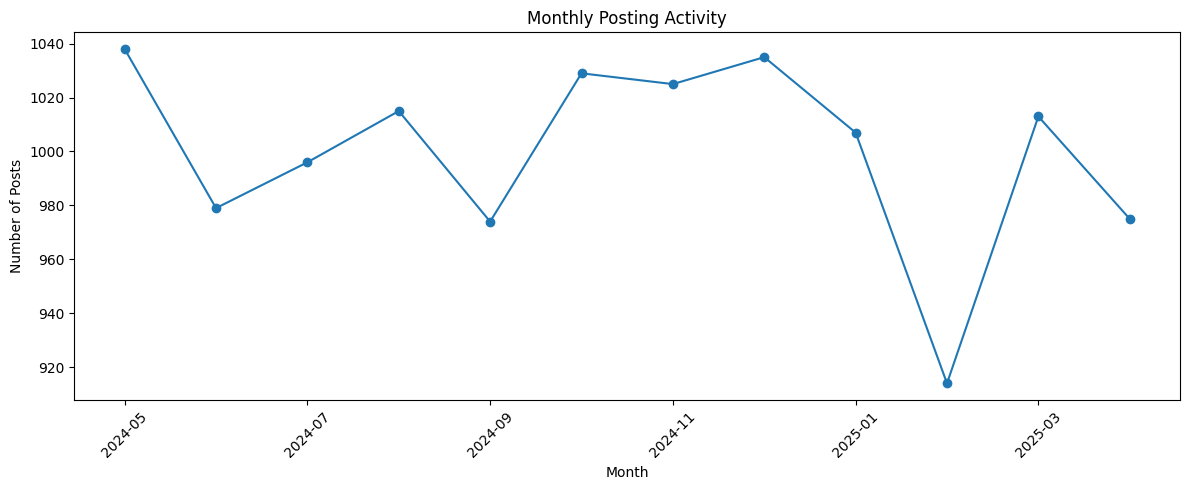

In [19]:
# Convert the monthly periods to strings for readable chart labels.
monthly_posts.index = monthly_posts.index.astype(str)

# Plot monthly posting activity.
plt.figure(figsize=(12, 5))

monthly_posts.plot(
    kind='line',
    marker='o'
)

plt.title('Monthly Posting Activity')
plt.xlabel('Month')
plt.ylabel('Number of Posts')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Insight

* Monthly posting activity remains relatively stable across the one-year
observation period, with most months containing approximately 975 to 1,038
posts.

* May 2024 records the highest posting volume with 1,038 posts, while February
2025 records the lowest with 914 posts. This represents a noticeable temporary
decline compared with the surrounding months.

* Posting activity increases again to 1,013 posts in March 2025 before declining
to 975 posts in April 2025.

* Overall, the dataset does not show a sustained upward or downward trend in
posting volume. Instead, posting activity fluctuates around a relatively
stable monthly level, with February 2025 standing out as the main low-activity
period.

## STEP 8 — Posting Activity by Hour

This section analyses the distribution of posts across the 24 hours of the day.

The hour is extracted from the standardised timestamp. This helps identify
periods of relatively higher or lower posting activity without assuming that
a higher posting frequency indicates higher engagement.

In [20]:
# Extract the hour of the day from each post timestamp.
posts['hour'] = posts['timestamp'].dt.hour

# Count the number of posts made during each hour.
hourly_posts = posts['hour'].value_counts().sort_index()

print("Posts by hour:")
print(hourly_posts)

Posts by hour:
hour
0     3902
1      362
2      357
3      384
4      342
5      329
6      344
7      340
8      346
9      357
10     366
11     348
12     360
13     352
14     320
15     354
16     311
17     354
18     341
19     379
20     345
21     368
22     351
23     388
Name: count, dtype: int64


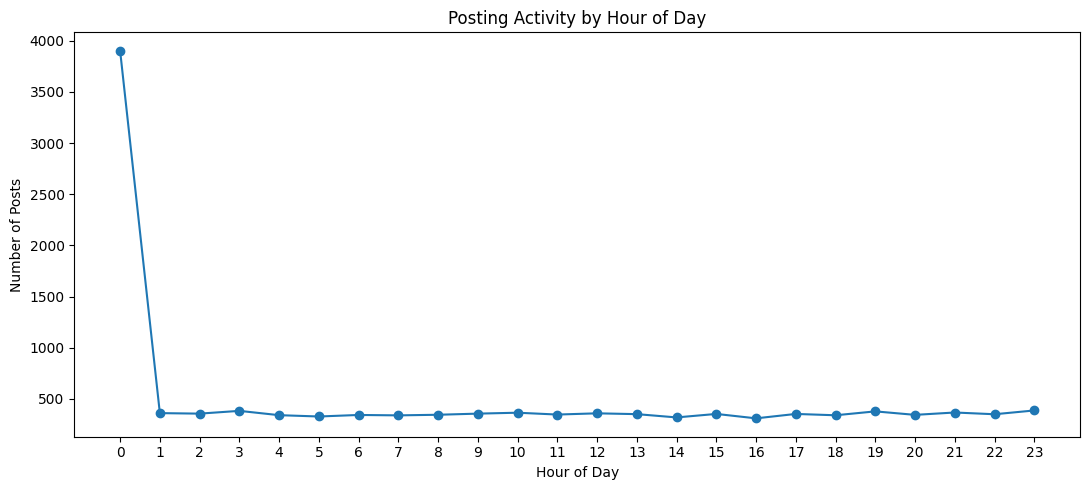

In [21]:
# Plot posting activity across the 24 hours of the day.

plt.figure(figsize=(11, 5))

hourly_posts.plot(
    kind='line',
    marker='o'
)

plt.title('Posting Activity by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Posts')
plt.xticks(range(24))

plt.tight_layout()
plt.show()

In [22]:
# Identify the hours with the highest and lowest posting activity.

highest_hour = hourly_posts.idxmax()
highest_count = hourly_posts.max()

lowest_hour = hourly_posts.idxmin()
lowest_count = hourly_posts.min()

print(f"Highest posting activity: {highest_hour}:00 ({highest_count} posts)")
print(f"Lowest posting activity: {lowest_hour}:00 ({lowest_count} posts)")

Highest posting activity: 0:00 (3902 posts)
Lowest posting activity: 16:00 (311 posts)


### Insight

* The hourly distribution shows an unusually large concentration of posts at
00:00, with 3,902 posts compared with approximately 300–400 posts in most
other hours.

* This concentration should not be interpreted as evidence that users primarily
post at midnight. During the earlier timestamp audit, several records were
observed with timestamps containing a date but no explicit time, which were
standardised to 00:00:00. Therefore, the large 00:00 concentration is likely
influenced by timestamps with unavailable time-of-day information.

* Among the non-midnight hours, posting activity is relatively evenly distributed,
with the lowest observed count at 16:00 (311 posts).

* Consequently, hour-level posting patterns should be interpreted cautiously,
as the dataset contains a substantial amount of time-of-day information
represented as 00:00:00.

## STEP 9 — Engagement Over Time

This section examines how average likes, shares, and comments vary across
the 12-month observation period.

Monthly averages are calculated separately for each engagement metric.
Missing likes are excluded from the likes average because they represent
unavailable values rather than zero engagement.

The analysis helps identify whether engagement levels show noticeable
temporal changes or remain relatively stable over the observation period.

In [23]:
# Create a month-level period from the standardised timestamp.
# The month column was already created in Step 7, so we reuse it.

monthly_engagement = posts.groupby('month')[
    ['likes', 'shares', 'comments']
].mean().round(2)

monthly_engagement

,likes,shares,comments
month,,,
2024-05,2453.78,992.53,510.56
2024-06,2410.80,998.87,504.01
2024-07,2454.31,1025.69,485.13
2024-08,2583.40,1019.43,494.40
2024-09,2537.61,1002.43,492.42
2024-10,2548.24,1004.93,511.66
2024-11,2511.91,1000.55,514.73
2024-12,2512.06,1039.64,504.36
2025-01,2412.43,997.88,499.66


<Figure size 1200x600 with 0 Axes>

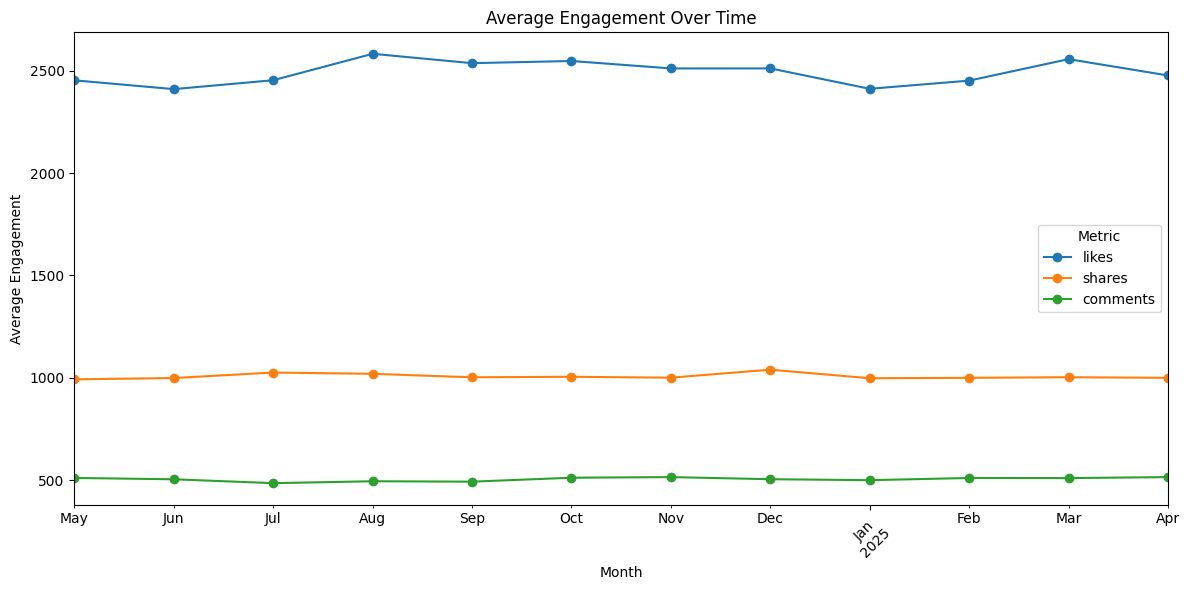

In [24]:
# Plot the monthly average for each engagement metric.

plt.figure(figsize=(12, 6))

monthly_engagement.plot(
    marker='o',
    figsize=(12, 6)
)

plt.title('Average Engagement Over Time')
plt.xlabel('Month')
plt.ylabel('Average Engagement')
plt.xticks(rotation=45)
plt.legend(title='Metric')

plt.tight_layout()
plt.show()

In [25]:
# Calculate the percentage change in monthly average engagement.
# This helps identify months with relatively large increases or decreases.

monthly_engagement_change = monthly_engagement.pct_change().round(3) * 100

monthly_engagement_change

,likes,shares,comments
month,,,
2024-05,NaN,NaN,NaN
2024-06,-1.8,0.6,-1.3
2024-07,1.8,2.7,-3.7
2024-08,5.3,-0.6,1.9
2024-09,-1.8,-1.7,-0.4
2024-10,0.4,0.2,3.9
2024-11,-1.4,-0.4,0.6
2024-12,0.0,3.9,-2.0
2025-01,-4.0,-4.0,-0.9


### Insight

* Average engagement remains relatively stable throughout the 12-month
observation period, with only moderate month-to-month fluctuations.

* Average likes range from approximately 2,411 in June 2024 to 2,583 in
August 2024. Average shares range from approximately 993 in May 2024 to
1,040 in December 2024, while average comments range from approximately
485 in July 2024 to 515 in November 2024.

* The largest month-to-month changes are still relatively limited. Average
likes increase by 5.3% from July to August 2024 and decrease by 4.0% from
December 2024 to January 2025. Average shares show their largest increase
of 3.9% in December 2024, while average comments increase by 3.9% in
October 2024.

* Overall, the dataset does not show a sustained increase or decrease in
average engagement over time. Engagement levels fluctuate around relatively
stable monthly averages rather than following a clear long-term trend.

* The first month has no percentage-change value because there is no previous
month within the dataset against which May 2024 can be compared.
* * Posting volume: fluctuates, with February 2025 noticeably lower.
  * Average engagement: remains relatively stable despite those changes in post volume.

## STEP 10 — User Posting Activity

This section examines how posts are distributed across users.

The number of posts created by each user is calculated to identify whether
posting activity is broadly distributed or concentrated among a smaller group
of users.

In [26]:
# Count the number of posts created by each user.
user_post_counts = posts['user_id'].value_counts()

# Display summary statistics for posts per user.
user_post_counts.describe()

,count
count,1500.000000
mean,8.000000
std,2.851214
min,1.000000
25%,6.000000
50%,8.000000
75%,10.000000
max,22.000000


In [28]:
# Display the 10 users with the highest number of posts.

top_users = user_post_counts.head(10)

top_users

,count
user_id,
user_zqv2vrf5,22
user_nfo3ih5u,19
user_8wk0j5ae,18
user_n0ok02rt,18
user_q3vs0uj7,18
user_0irp4abu,17
user_xetn4exw,16
user_ujllj1n7,16
user_i1e1kek5,16


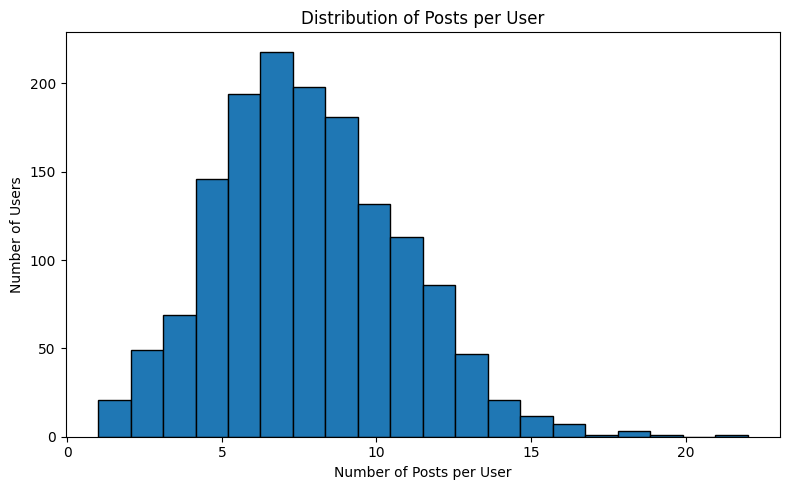

In [27]:
# Plot the distribution of posts per user.

plt.figure(figsize=(8, 5))

user_post_counts.plot(
    kind='hist',
    bins=20,
    edgecolor='black'
)

plt.title('Distribution of Posts per User')
plt.xlabel('Number of Posts per User')
plt.ylabel('Number of Users')

plt.tight_layout()
plt.show()

### Insight

* Posting activity is distributed across all 1,500 users, with an average of
8 posts per user and a median of 8 posts per user.

* The number of posts per user ranges from 1 to 22, with a standard deviation
of approximately 2.85. The middle 50% of users have between 6 and 10 posts,
indicating that posting activity is relatively concentrated around the
dataset average.

* The most active user has 22 posts, which is higher than the average but does
not indicate extreme concentration of posts in a small number of users.

* Overall, the dataset provides contributions from all 1,500 users, with no
users completely absent from the Posts dataset. This suggests that the
dataset has broad user-level coverage rather than being dominated by a small
subset of users.

## STEP 11 — Engagement Outlier Analysis

This section identifies potential outliers in the engagement metrics using
the Interquartile Range (IQR) method.

For each metric, the lower and upper bounds are calculated as:

Lower Bound = Q1 − 1.5 × IQR
Upper Bound = Q3 + 1.5 × IQR

Values outside these bounds are flagged as potential statistical outliers.
These observations are not removed automatically because an extreme
engagement value may represent a legitimate observation rather than a data
quality error.

In [29]:
# Define the engagement metrics to analyse.
engagement_columns = ['likes', 'shares', 'comments']

# Calculate IQR-based outlier statistics for each metric.
outlier_summary = []

for column in engagement_columns:

    # Drop missing values because they cannot be evaluated as outliers.
    values = posts[column].dropna()

    # Calculate the first and third quartiles.
    Q1 = values.quantile(0.25)
    Q3 = values.quantile(0.75)

    # Calculate the interquartile range.
    IQR = Q3 - Q1

    # Calculate the statistical outlier boundaries.
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Count values outside the calculated boundaries.
    outlier_count = ((values < lower_bound) | (values > upper_bound)).sum()

    outlier_summary.append({
        'Metric': column,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound,
        'Outlier Count': outlier_count,
        'Outlier Percentage': round(
            (outlier_count / len(values)) * 100, 2
        )
    })

# Convert the results into a DataFrame.
outlier_summary = pd.DataFrame(outlier_summary)

outlier_summary

,Metric,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage
0,likes,1240.0,3724.0,2484.0,-2486.0,7450.0,0,0.0
1,shares,510.0,1501.0,991.0,-976.5,2987.5,0,0.0
2,comments,253.0,755.0,502.0,-500.0,1508.0,0,0.0


### Insight

* The IQR-based analysis identifies no statistical outliers in likes, shares,
or comments.

* For likes, the calculated upper bound is 7,450, which is above the observed
maximum of 5,000. Similarly, the upper bounds for shares and comments are
2,987.5 and 1,508 respectively, both above their observed maximum values of
2,000 and 1,000.

* As a result, none of the valid engagement observations fall outside the
IQR-based outlier boundaries.

* This indicates that the engagement values are contained within their expected
statistical ranges after the earlier correction of negative likes. Therefore,
no additional outlier removal is required based on the IQR criterion.

## STEP 12 — Final EDA Summary

### Key Findings

1. The dataset contains 12,000 posts from 1,500 users, with every user in the
Users dataset having at least one corresponding post.

2. The five identified platforms have relatively balanced post volumes, with
Facebook and YouTube having the highest counts among the known platforms.
However, 14.87% of posts have missing platform information.

3. Engagement values cover broad ranges: likes range from 0 to 5,000, shares
from 0 to 2,000, and comments from 0 to 1,000. Missing likes remain present
and were not interpreted as zero.

4. No single platform consistently leads across likes, shares, and comments.
YouTube and Facebook have the highest average likes, Instagram has the
highest average shares, and Reddit has the highest average comments.

5. Likes, shares, and comments show almost no linear correlation with one
another. This suggests that the three engagement metrics behave largely
independently within this dataset.

6. Monthly posting activity remains relatively stable across the observation
period, although February 2025 has the lowest number of posts.

7. Average engagement also remains relatively stable over time, with only
moderate month-to-month fluctuations and no clear sustained upward or
downward trend.

8. Posting activity is broadly distributed across users. The average and
median are both 8 posts per user, while the most active user has 22 posts.

9. Hour-level posting analysis is affected by a large concentration of
timestamps at 00:00, partly because some source timestamps contained dates
without explicit time information. Therefore, hourly activity should be
interpreted cautiously.

10. No IQR-based statistical outliers were identified in likes, shares, or
comments after the data-cleaning process.

In [30]:
# Remove temporary columns created only for EDA.
# These columns should not be part of the final cleaned dataset.

posts.drop(columns=['month', 'hour'], inplace=True, errors='ignore')

print("Final columns:")
print(posts.columns.tolist())

Final columns:
['post_id', 'user_id', 'platform', 'text_content', 'timestamp', 'likes', 'shares', 'comments']
